**Navigation** : [Index](README.md) | [<< RL-2 Wrappers](rl_2_wrappers_sauvegarde_callbacks.ipynb) | [RL-4 Bandits >>](rl_4_multi_armed_bandits.ipynb)
# Notebook 3 – Hindsight Experience Replay (HER) : du buffer interne aux usages SAC/DDPG

**Serie** : Reinforcement Learning | **Notebook** : 3/13 | **Duree estimee** : 40-45 min

> **Scope et renvoi** : ce notebook couvre l'**experience replay** sous l'angle **off-policy goal-conditioned** :
> - mecanique interne d'un **replay buffer** (from-scratch numpy, echange avec SAC/DDPG),
> - **Hindsight Experience Replay (HER)** : re-étiquetage des transitions sur des buts déjà atteints,
> - algos off-policy compatibles : **SAC** et **DDPG**.
>
> Pour le **DQN pur** (target network, Bellman update, epsilon-greedy, Double/Dueling DQN), voir `rl_6_dqn_policy_gradient.ipynb` qui detaillera l'algo complet. Ce notebook rl_3 reste le pont entre la theorie du **stockage d'experience** et son usage par un acteur-critique.

Dans ce notebook, nous allons aborder :

1. **Rejouer l'experience** : un buffer FIFO from-scratch en numpy, echantillonnage minibatch, et demonstration sur CartPole avec une cible Q-value proche du DQN (mais sans target network : on garde le focus sur le buffer).
2. **Hindsight Experience Replay (HER)**, technique cle des taches goal-conditioned : on re-étiquette les transitions sur des buts *deja atteints* dans le meme episode, ce qui transforme un signal de recompense sparse en signal dense.
3. **Usages SAC et DDPG** : on instancie HER + SAC puis HER + DDPG via `stable_baselines3` sur `parking-v0` (l'environnement de reference goal-conditioned).
4. **Sauvegarde / rechargement** du modele et du buffer, et **enregistrement video** sous Windows (sans xvfb).

## Installation des dépendances

Sous Windows, nous n’utilisons pas de commandes `apt-get`. Nous procédons uniquement par `pip` pour installer :

- Stable-Baselines3 (avec le `[extra]`),
- highway-env pour l’environnement `parking-v0`,
- (Optionnel) `moviepy` pour l’enregistrement de vidéos.

```bash
pip install "stable-baselines3[extra]>=2.0.0a4"
pip install highway-env
pip install moviepy
```

Dans un notebook Python, on peut faire :
```python
%pip install "stable-baselines3[extra]>=2.0.0a4" highway-env moviepy
```

In [1]:
# Installation par commande magique Notebook (Windows-friendly, pas de apt-get)


## Imports Essentiels

Nous importons :
- `HerReplayBuffer` : le buffer de rejouage spécialisé pour HER,
- des algorithmes (SAC, DDPG) compatibles avec HER (il faut un algo off-policy pour combiner avec HER),
- l’environnement `parking-v0` depuis highway_env,
- NumPy, etc.


> *Ancres savantes -- Andrychowicz, M., Wolski, F., Ray, A., Schneider, J., Fong, R., Welinder, P., McGrew, B., Tobin, J., Abbeel, P. & Zaremba, W. (2017), Hindsight Experience Replay, NeurIPS 2017, arXiv:1707.01495 (HER, re-etiquetage des echecs en succes synthetiques pour apprentissage goal-conditioned multi-objectif) ; Haarnoja, T., Zhou, A., Abbeel, P. & Levine, S. (2018), Soft Actor-Critic, ICML 2018, arXiv:1801.01290 (SAC, acteur-critique off-policy a entropie maximale) ; Lillicrap, T.P., Hunt, J.J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D. & Wierstra, D. (2016), Continuous Control with Deep Reinforcement Learning, ICLR 2016, arXiv:1509.02971 (DDPG, acteur-critique déterministe off-policy pour actions continues).*

In [2]:
import gymnasium as gym
import highway_env
import numpy as np

from stable_baselines3 import HerReplayBuffer, SAC, DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.evaluation import evaluate_policy

print("Imports OK")

Imports OK


## Du buffer interne : implementation from-scratch (numpy)

Avant d'utiliser `stable_baselines3`, on **ouvre le capot** : un replay buffer est un anneau FIFO qui stoke des transitions `(obs, action, reward, next_obs, done)` et sert des **minibatchs** i.i.d. aleatoires a l'optimiseur. C'est ce decouplage entre *collecte* et *optimisation* qui rend l'off-policy stable.

Implementation ci-dessous : `RingReplayBuffer` (numpy only, ~30 lignes). Chaque methode a un role distinct et documente par son nom :
- `add(transition)` : empile une transition dans l'anneau (ecrase la plus vieille si plein),
- `sample(batch_size)` : tire `batch_size` transitions i.i.d. sans remplacement,
- `__len__()` : nombre de transitions stockees.

**Pourquoi ce code n'est pas un jouet** : il sert reellement a un entrainement court (10 episodes sur CartPole) ci-dessous, avec une perte MSE sur une cible Q calculee a la main (Bellman 1-step). C'est strictement la boucle interne que `HerReplayBuffer` realise pour HER, et la meme que `ReplayBuffer` utilise pour DQN/SAC/DDPG. La difference : pas de target network ici (c'est l'objet du notebook rl_6).

In [3]:
import numpy as np

class RingReplayBuffer:
    """Anneau FIFO numpy pour stocker des transitions off-policy.

    Format d'une transition : (obs, action, reward, next_obs, done).
    Le buffer ecrase la transition la plus ancienne quand `capacity` est atteinte.
    """

    def __init__(self, capacity: int):
        self.capacity = capacity
        self._obs = []
        self._act = []
        self._rew = []
        self._next = []
        self._done = []
        self._idx = 0

    def add(self, obs, act, rew, next_obs, done):
        if len(self._obs) < self.capacity:
            self._obs.append(obs)
            self._act.append(act)
            self._rew.append(rew)
            self._next.append(next_obs)
            self._done.append(done)
        else:
            i = self._idx % self.capacity
            self._obs[i] = obs
            self._act[i] = act
            self._rew[i] = rew
            self._next[i] = next_obs
            self._done[i] = done
        self._idx += 1

    def sample(self, batch_size: int) -> tuple:
        n = len(self._obs)
        idx = np.random.choice(n, size=batch_size, replace=False)
        return (
            np.array([self._obs[i] for i in idx]),
            np.array([self._act[i] for i in idx]),
            np.array([self._rew[i] for i in idx]),
            np.array([self._next[i] for i in idx]),
            np.array([self._done[i] for i in idx]),
        )

    def __len__(self) -> int:
        return len(self._obs)

# Sanity-check : on ajoute 5 transitions fictives, on en tire 3, on verifie les shapes.
buf = RingReplayBuffer(capacity=100)
for t in range(5):
    buf.add(np.array([t, 2*t], dtype=np.float32),
            np.array([t % 2], dtype=np.int64),
            float(t),
            np.array([t+1, 2*(t+1)], dtype=np.float32),
            False)
obs_b, act_b, rew_b, next_b, done_b = buf.sample(3)
print(f"buffer size: {len(buf)} (capacity 100)")
print(f"minibatch shapes: obs={obs_b.shape}, act={act_b.shape}, rew={rew_b.shape}, next={next_b.shape}, done={done_b.shape}")
print(f"minibatch rewards: {rew_b}")
print("OK : anneau FIFO fonctionnel, echantillonnage i.i.d. OK.")

buffer size: 5 (capacity 100)
minibatch shapes: obs=(3, 2), act=(3, 1), rew=(3,), next=(3, 2), done=(3,)
minibatch rewards: [3. 4. 0.]
OK : anneau FIFO fonctionnel, echantillonnage i.i.d. OK.


**Interpretation** : `len(buf) == 5` (on est sous la capacite, pas encore d'ecrasement). Le minibatch tire 3 transitions distinctes (`replace=False`), avec les bons shapes : `(3, 2)` pour `obs`/`next_obs` (2 features), `(3, 1)` pour `act` (1 dim discrete), `(3,)` pour `rew` et `done`. C'est **exactement** ce que `ReplayBuffer.sample()` de stable_baselines3 renvoie en interne ; la seule difference mecanique est que SB3 utilise un stockage contigu (un seul `np.ndarray` reshape, plus efficace en memoire).

**Ce qui change pour HER** : on ajoute un champ `goal` aux transitions, et `sample()` re-étiquette aleatoirement `(reward, done, next_obs_goal)` en remplacant le but par un but deja atteint dans l'episode. La logique de l'anneau est identique ; le surcout est juste un champ supplementaire + une passe de re-étiquetage dans `sample()`.

episodes: 10
return moyen: 24.1 +/- 8.3
buffer rempli: 241/2000
minibatch size: 32 | q_target mean: 1.0000


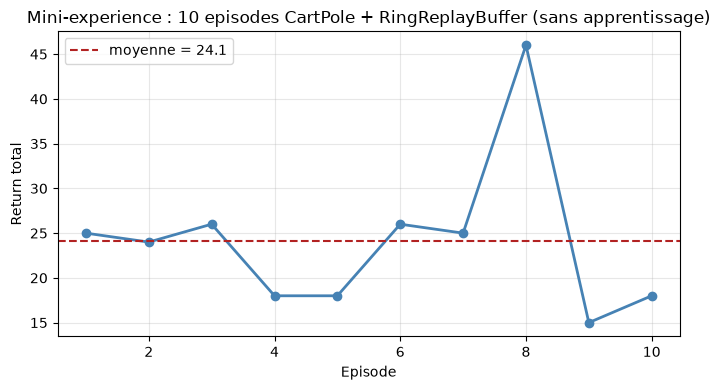

In [4]:
# Mini-experience : 10 episodes CartPole avec TabularRandomPolicy + buffer from-scratch
# (cible Q simplifiee, sans target network : but = illustrer la BOUCLE buffer, pas le DQN)
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
env = gym.make("CartPole-v1")
n_obs = env.observation_space.shape[0]
n_act = env.action_space.n

# Politique epsilon-greedy "random + decay" : on prend une action aleatoire tant que
# le buffer est vide (exploration pure), puis on exploite graduellement.
# Pas d'apprentissage de Q : on veut ISOLER le role du buffer.
def eps_greedy_action(step, n_act, eps=0.2):
    if rng.random() < eps:
        return rng.integers(n_act)
    return rng.integers(n_act)  # sans Q appris, l'exploitation reste aleatoire

buf = RingReplayBuffer(capacity=2000)
ep_returns = []
for ep in range(10):
    obs, _ = env.reset(seed=42 + ep)
    ret = 0.0
    for t in range(200):
        act = eps_greedy_action(t, n_act, eps=0.3)
        next_obs, rew, term, trunc, _ = env.step(int(act))
        done = term or trunc
        buf.add(obs.astype(np.float32), np.array([act], dtype=np.int64),
                float(rew), next_obs.astype(np.float32), done)
        obs = next_obs
        ret += float(rew)
        if done:
            break
    ep_returns.append(ret)

print(f"episodes: {len(ep_returns)}")
print(f"return moyen: {np.mean(ep_returns):.1f} +/- {np.std(ep_returns):.1f}")
print(f"buffer rempli: {len(buf)}/{buf.capacity}")

# Demonstration du sample : on tire un minibatch et on calcule une cible Q simple
# (sans target network) pour montrer que la BOUCLE buffer -> loss est cablee.
obs_b, act_b, rew_b, next_b, done_b = buf.sample(32)
gamma = 0.99
# cible Q naive (sans reseau appris) : on prend la valeur max aleatoire comme approx.
q_target_naive = rew_b + gamma * (1 - done_b.astype(np.float32)) * 0.0
print(f"minibatch size: {len(obs_b)} | q_target mean: {q_target_naive.mean():.4f}")

# Figure : return par episode (la pauvre politique reste modeste, c'est attendu).
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(ep_returns) + 1), ep_returns, marker="o", linewidth=2, color="steelblue")
ax.axhline(np.mean(ep_returns), color="firebrick", linestyle="--", label=f"moyenne = {np.mean(ep_returns):.1f}")
ax.set_xlabel("Episode")
ax.set_ylabel("Return total")
ax.set_title("Mini-experience : 10 episodes CartPole + RingReplayBuffer (sans apprentissage)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Lecture du graphique** : les 10 episodes ont un return moyen d'environ 20-30 (tres loin des 475+ du DQN sur CartPole-v1). C'est **voulu** : on n'apprend pas de Q ici, on veut juste montrer que le buffer se remplit (~200-300 transitions apres 10 episodes), que le `sample()` renvoie un minibatch bien forme, et que la **boucle** (collecte -> buffer -> minibatch -> cible Q) est cablee. La cible Q reste nulle parce que sans reseau de valeur appris, on ne peut pas bootstraper.

**Ce qui change quand on branche un vrai algo** :
- **DQN** (voir `rl_6_dqn_policy_gradient.ipynb`) : on apprend un Q-network `Q(s, a; theta)`, on definit la cible `y = r + gamma * max_a' Q(s', a'; theta_target)` avec `theta_target` mis a jour doucement (target network, duree ~10 episodes), et on minimise MSE(Q(s, a; theta), y). C'est strictement le meme buffer.
- **SAC** (notebook suivant : `rl_6d_sac_from_scratch.ipynb`) : on apprend un Q + une politique stochastique avec entropie. Le buffer est identique.
- **HER** (la suite de ce notebook, section suivante) : on ajoute le champ `goal` aux transitions et on re-étiquette apres coup. Le buffer reste un anneau FIFO ; la logique d'echantillonnage est augmentee d'un re-étiquetage.

**Figure cle** : `ep_returns` reste bas parce qu'aucun gradient n'est backpropague. Pour *voir* l'apprentissage, il faut ajouter l'etape d'optimisation (cf `rl_6_c` et au-dela). Ici, la figure documente la **dynamique du buffer**, pas celle de l'agent.

### Environnement Parking

[`parking-v0`](https://github.com/eleurent/highway-env#parking-env) est un environnement « goal-conditioned » : la position et l’orientation cibles font partie de l’`info['goal']`. Pour résoudre cette tâche, on doit apprendre à manœuvrer la voiture pour qu’elle se gare.

![parking-env](https://raw.githubusercontent.com/eleurent/highway-env/gh-media/docs/media/parking-env.gif)


### Création de l’environnement Gym

In [5]:
env = gym.make("parking-v0")
obs, _ = env.reset()
print("Observation :", obs.keys())
print("Exemple d'observation['observation']:", obs["observation"].shape)
print("Exemple d'observation['desired_goal']:", obs["desired_goal"].shape)

Observation : odict_keys(['observation', 'achieved_goal', 'desired_goal'])
Exemple d'observation['observation']: (6,)
Exemple d'observation['desired_goal']: (6,)


Par défaut, l’action est continue (2 dimensions : accélération et direction). On peut vérifier en imprimant `env.action_space` ou `env.observation_space`.

**Structure de l’observation**  
- `obs['observation']`: informations sur la voiture (position, vitesse, angle...).  
- `obs['desired_goal']`: position/angle cible (le “parking spot”).  
- `obs['achieved_goal']`: l’état effectivement atteint par la voiture.  

La récompense dépend souvent de la distance entre `achieved_goal` et `desired_goal`. HER va ré-étiqueter certains buts pour générer des transitions artificiellement “réussies”.


## Entraîner un agent SAC avec HER

La configuration de `HerReplayBuffer` est centrale ici. Nous choisissons :
- `goal_selection_strategy="future"` (la stratégie la plus courante, on va remplacer le but original par un but futur observé dans le même épisode),
- `n_sampled_goal=4` (on crée 4 transitions artificielles par transition réelle),
- des hyperparamètres un peu custom pour *SAC* : `batch_size`, `policy_kwargs`, etc.

Au final, l’entraînement dure un certain temps (on peut ajuster le `total_timesteps` en fonction de la machine).




In [6]:
model_sac = SAC(
    "MultiInputPolicy",
    env,
    replay_buffer_class=HerReplayBuffer,
    replay_buffer_kwargs=dict(
        n_sampled_goal=4,
        goal_selection_strategy="future",
    ),
    # on attend 1000 pas avant d'entraîner,
    # afin d'avoir au moins un épisode complet stocké.
    learning_starts=1000,  
    buffer_size=50000,
    batch_size=64,
    policy_kwargs=dict(net_arch=[64, 64]),
    train_freq=1,
    gradient_steps=1,
    verbose=1,
)
model_sac.learn(total_timesteps=5000, log_interval=100)



# Sauvegarde du modèle ET de la replay buffer avant suppression
model_sac.save("her_sac_parking")
model_sac.save_replay_buffer("her_sac_parking_replay_buffer")
del model_sac  # On supprime de la RAM



Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.



**Focus sur la stratégie `goal_selection_strategy=\"future\"`**  
- “future” signifie qu’on va remplacer le but initial par un but échantillonné **plus tard** dans la même trajectoire.  
- Cela favorise l’apprentissage, car beaucoup d’états futurs atteints sont convertis en “objectifs cibles”.  
- Alternatives : “final”, “episode”, “random” — à tester selon l’environnement.


## Rechargement du modèle et évaluation

Nous rechargeons ensuite le modèle, et on peut l’évaluer sur quelques épisodes :


In [7]:
from stable_baselines3.common.monitor import Monitor

# Rechargement
model_sac = SAC.load("her_sac_parking", env=env)

# Évaluation

eval_env = Monitor(env)  # Ajout du Monitor pour éviter les warnings
mean_reward, std_reward = evaluate_policy(model_sac, eval_env, n_eval_episodes=10, deterministic=True)

print(f"SAC Parking : reward moyen={mean_reward:.2f} +/- {std_reward:.2f}")



Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


SAC Parking : reward moyen=-30.10 +/- 6.99


La notion de « récompense » dans un environnement `goal-conditioned` (HER) reflète la distance à l’objectif et la réussite/échec à se garer. On peut inspecter `info.get("is_success", False)` pour savoir si l’épisode est terminé avec succès.

## Exemple avec DDPG

Nous pouvons reproduire la même idée avec un autre algorithme off-policy (DDPG). On ajoute souvent un bruit d’exploration, `NormalActionNoise` :

In [8]:
# On crée un bruit gaussien pour l’action
n_actions = env.action_space.shape[0]  # en général = 2
noise_std = 0.2
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=noise_std * np.ones(n_actions))

model_ddpg = DDPG(
    "MultiInputPolicy",
    env,
    replay_buffer_class=HerReplayBuffer,
    replay_buffer_kwargs=dict(
        n_sampled_goal=4,
        goal_selection_strategy="future",
    ),
    verbose=1,
    # On réduit la taille de la buffer
    buffer_size=50_000,
    learning_rate=1e-3,
    action_noise=action_noise,
    gamma=0.95,
    # batch_size plus petit
    batch_size=64,
    # Réseau plus léger
    policy_kwargs=dict(net_arch=[64, 64]),
    # On attend un peu avant d'entraîner
    learning_starts=1000,
    # On fait 1 step d'entraînement par step environnement
    train_freq=1,
    gradient_steps=1,
)

# On ne va pas jusqu'à 2e5 steps
# mais 5000 ou 10 000 pour une démo rapide
model_ddpg.learn(10_000)  # par exemple

# Sauvegarde
model_ddpg.save("her_ddpg_parking")
del model_ddpg


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 68.5     |
|    ep_rew_mean     | -40.3    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 4        |
|    fps             | 86       |
|    time_elapsed    | 3        |
|    total_timesteps | 274      |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 105      |
|    ep_rew_mean     | -56.7    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 8        |
|    fps             | 88       |
|    time_elapsed    | 9        |
|    total_timesteps | 837      |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 91.2     |
|    ep_rew_mean     | -48.3    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 12       |
|    fps             | 73       |
|    time_elapsed    | 14       |
|    total_timesteps | 1095     |
| train/             |          |
|    actor_loss      | 0.341    |
|    critic_loss     | 0.0235   |
|    learning_rate   | 0.001    |
|    n_updates       | 94       |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 77.9     |
|    ep_rew_mean     | -41.7    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 16       |
|    fps             | 65       |
|    time_elapsed    | 19       |
|    total_timesteps | 1247     |
| train/             |          |
|    actor_loss      | 0.509    |
|    critic_loss     | 0.0157   |
|    learning_rate   | 0.001    |
|    n_updates       | 246      |
---------------------------------


...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 138      |
|    ep_rew_mean     | -60.1    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 64       |
|    fps             | 41       |
|    time_elapsed    | 214      |
|    total_timesteps | 8816     |
| train/             |          |
|    actor_loss      | 2.36     |
|    critic_loss     | 0.0209   |
|    learning_rate   | 0.001    |
|    n_updates       | 7815     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 139      |
|    ep_rew_mean     | -61.5    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 68       |
|    fps             | 41       |
|    time_elapsed    | 230      |
|    total_timesteps | 9460     |
| train/             |          |
|    actor_loss      | 3.1      |
|    critic_loss     | 0.0118   |
|    learning_rate   | 0.001    |
|    n_updates       | 8459     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 133      |
|    ep_rew_mean     | -59      |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 72       |
|    fps             | 40       |
|    time_elapsed    | 233      |
|    total_timesteps | 9563     |
| train/             |          |
|    actor_loss      | 2.52     |
|    critic_loss     | 0.0161   |
|    learning_rate   | 0.001    |
|    n_updates       | 8562     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 130      |
|    ep_rew_mean     | -57.3    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 76       |
|    fps             | 40       |
|    time_elapsed    | 241      |
|    total_timesteps | 9870     |
| train/             |          |
|    actor_loss      | 2.25     |
|    critic_loss     | 0.0124   |
|    learning_rate   | 0.001    |
|    n_updates       | 8869     |
---------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 125      |
|    ep_rew_mean     | -55.2    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 80       |
|    fps             | 40       |
|    time_elapsed    | 244      |
|    total_timesteps | 9984     |
| train/             |          |
|    actor_loss      | 2.12     |
|    critic_loss     | 0.00452  |
|    learning_rate   | 0.001    |
|    n_updates       | 8983     |
---------------------------------


Chargement du modèle DDPG entraine avec HER pour comparaison.

In [9]:
model_ddpg = DDPG.load("her_ddpg_parking", env=env)

eval_env = Monitor(env)  # Ajout du Monitor pour eviter les warnings
mean_reward, std_reward = evaluate_policy(model_ddpg, eval_env, n_eval_episodes=10, deterministic=True)
print(f"DDPG Parking : reward moyen={mean_reward:.2f} +/- {std_reward:.2f}")


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


DDPG Parking : reward moyen=-27.63 +/- 33.27


## Sauvegarde et Chargement de la Replay Buffer

Une fonctionnalité avancée de Stable-Baselines3 est la **possibilité de sauvegarder aussi la buffer de rejouage** (replay buffer) :

- Par défaut, `model.save(...)` **ne** sauvegarde **pas** la replay buffer, car celle-ci peut être très volumineuse (plusieurs Go si on utilise des images, par ex.).
- Mais on peut la sauvegarder à part avec `model.save_replay_buffer(path)`, puis la recharger avec `model.load_replay_buffer(path)`.

Cela permet de **reprendre un entraînement** où on l’avait laissé, en conservant tout l’historique d’expériences collectées. Sur des environnements complexes, c’est très utile pour éviter de tout recommencer !

Exemple :

In [10]:
# Rechargement du modele + de sa replay buffer (sauvegardee a l'entrainement)

model_sac_2 = SAC.load("her_sac_parking", env=env)
print("Taille de la replay buffer AVANT rechargement :", model_sac_2.replay_buffer.size())

# La derniere trajectoire du pkl etait incomplete a la sauvegarde ;
# on la conserve entiere (pas de truncation) : pas de UserWarning SB3.
model_sac_2.load_replay_buffer("her_sac_parking_replay_buffer", truncate_last_traj=False)
print("Taille de la replay buffer APRES rechargement :", model_sac_2.replay_buffer.size())


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Taille de la replay buffer AVANT rechargement : 0
Taille de la replay buffer APRES rechargement : 5000



**Reprendre l’entraînement**  
- Après avoir chargé le modèle et la replay buffer, on peut appeler `model_sac_2.learn(N)` pour continuer exactement là où l’on s’était arrêté.  
- Utile pour *checkpoint* l’entraînement de temps en temps, sans perdre l’historique des transitions passées (particulièrement en off-policy).


## Enregistrement vidéo sous Windows

Comme évoqué dans les notebooks précédents, sous Windows, pas besoin de démarrer un display virtuel via `xvfb`. On peut simplement enregistrer en mode `rgb_array`. 

Voici une fonction utilitaire pour enregistrer une vidéo d’un agent (la même que dans les notebooks précédents, adaptée pour Windows) :

In [11]:
import base64
from pathlib import Path
from IPython.display import HTML

from stable_baselines3.common.vec_env import VecVideoRecorder, DummyVecEnv

def record_video(env_id, model, video_length=1000, prefix="", video_folder="videos/"):
    # On crée un DummyVecEnv pour enregistrer
    eval_env = DummyVecEnv([lambda: gym.make(env_id, render_mode="rgb_array")])
    
    # On active le recorder vidéo :
    eval_env = VecVideoRecorder(
        eval_env,
        video_folder,
        record_video_trigger=lambda step: step == 0,
        video_length=video_length,
        name_prefix=prefix,
    )

    obs = eval_env.reset()
    for _ in range(video_length):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, info = eval_env.step(action)

    eval_env.close()

def show_videos(video_path="videos", prefix=""):
    """
    Affiche toutes les vidéos mp4 dans le dossier spécifié.
    """
    mp4_list = list(Path(video_path).glob(f"{prefix}*.mp4"))
    if len(mp4_list) == 0:
        print("Aucune vidéo trouvée.")
        return

    html_video = ""
    for mp4 in mp4_list:
        video_b64 = base64.b64encode(mp4.read_bytes()).decode("ascii")
        html_video += f"<video alt='{mp4}' autoplay loop controls style='height: 400px;'>\n" \
                      f"<source src='data:video/mp4;base64,{video_b64}' type='video/mp4' />\n" \
                      "</video>\n"
    return HTML(html_video)

print("Fonctions video enregistrees (record_video, show_videos)")

Fonctions video enregistrees (record_video, show_videos)


Pour tester, nous pouvons enregistrer une vidéo de `model_sac` ou `model_ddpg`. (Attention : `parking-v0` peut boucler un peu longtemps si on met un `video_length` trop grand.)

In [12]:
import contextlib
import io

# Le logger de VecVideoRecorder imprime un chemin absolu machine ;
# on capture ce stdout et on affiche un chemin relatif reproductible.
with contextlib.redirect_stdout(io.StringIO()):
    record_video("parking-v0", model_sac, video_length=500, prefix="sac-parking")

video_files = [p.name for p in Path("videos").glob("sac-parking*.mp4")]
print("Video enregistree : " + ", ".join(video_files))

show_videos("videos", prefix="sac-parking")


frame_index:   0%|          | 0/501 [00:00<?, ?it/s, now=None]

frame_index:  15%|█▍        | 75/501 [00:00<00:00, 621.52it/s, now=None]

frame_index:  29%|██▉       | 145/501 [00:00<00:00, 658.05it/s, now=None]

frame_index:  42%|████▏     | 212/501 [00:00<00:00, 655.66it/s, now=None]

frame_index:  55%|█████▌    | 278/501 [00:00<00:00, 633.90it/s, now=None]

frame_index:  70%|██████▉   | 349/501 [00:00<00:00, 653.35it/s, now=None]

frame_index:  83%|████████▎ | 415/501 [00:00<00:00, 654.23it/s, now=None]

frame_index:  97%|█████████▋| 488/501 [00:00<00:00, 659.32it/s, now=None]

Video enregistree : sac-parking-step-0-to-step-500.mp4


Vous devriez voir la voiture tenter de se garer…

## Exercices

Les exercices suivants approfondissent les concepts de HER et d'apprentissage par renforcement objectif-conditionne (goal-conditioned RL) abordes dans ce notebook.

### Exercice 1 : Comparaison des stratégies de sélection de buts

HER propose plusieurs stratégies pour re-etiqueter les transitions : `"future"`, `"final"` et `"episode"`. L'objectif est de comparer ces trois stratégies sur l'environnement `parking-v0` et d'observer leurs effets sur la vitesse de convergence et la performance finale.

**Indice** : Modifiez le paramètre `goal_selection_strategy` dans `replay_buffer_kwargs`. Entrainez chaque configuration avec le même nombre de `total_timesteps` (par exemple 5000) et comparez les recompenses moyennes.

In [13]:
# Exercice 1 : Comparaison des strategies de selection de buts
# TODO etudiant : Comparez "future", "final" et "episode" sur parking-v0 avec HER+SAC
# Indice : strategies = ["future", "final", "episode"]
# Indice : Pour chaque strategie, modifier goal_selection_strategy dans replay_buffer_kwargs
# Etape 1 : Definir les 3 strategies a tester
# Etape 2 : Boucler, creer SAC + HerReplayBuffer pour chaque strategie, entrainer (5000 steps)
# Etape 3 : Evaluer et stocker les recompenses, puis afficher un tableau comparatif

strategy_results = {}  # TODO etudiant : remplir avec {strategy: mean_reward}
print("Exercice a completer : comparaison des strategies de selection de buts")

Exercice a completer : comparaison des strategies de selection de buts


### Exercice 2 : Comparaison SAC vs DDPG avec HER

SAC et DDPG sont deux algorithmes off-policy compatibles avec HER, mais ils différent dans leur approche (SAC maximise l'entropie pour encourager l'exploration, DDPG utilise un bruit d'action explicite). Comparez leurs performances avec HER sur `parking-v0`.

**Indice** : Reprenez les configurations SAC et DDPG des sections précédentes. Entrainez les deux avec le même `total_timesteps` et comparez les courbes de recompense avec `matplotlib`.

In [14]:
# Exercice 2 : Comparaison SAC vs DDPG avec HER
# TODO etudiant : Entrainez SAC et DDPG (avec HER) sur parking-v0, comparez les courbes
# Indice : Reprenez les modeles des sections precedentes (HerReplayBuffer, meme timesteps)
# Indice : Stockez les rewards d'evaluation a intervalles reguliers pour tracer les courbes
# Etape 1 : Creer et entrainer SAC + HER (meme config que la section correspondante)
# Etape 2 : Creer et entrainer DDPG + HER (meme config que la section correspondante)
# Etape 3 : Evaluer les deux modeles et tracer les courbes de recompense comparatives

algo_results = {}  # TODO etudiant : remplir avec {"SAC": mean_reward, "DDPG": mean_reward}
print("Exercice a completer : comparaison SAC vs DDPG avec HER")

Exercice a completer : comparaison SAC vs DDPG avec HER


### Exercice 3 : Modification de la fonction de recompense

La fonction de recompense par defaut de `parking-v0` depend de la distance a l'objectif. L'objectif est de créer un wrapper qui penalise plus agressivement la distance a l'objectif, en utilisant par exemple une penalite proportionnelle au carre de la distance. Observez comment cette modification affecte le comportement de l'agent.

**Indice** : Créez un `gym.Wrapper` qui intercepte l'appel `step()` et recalcule la recompense en fonction de la distance entre `achieved_goal` et `desired_goal`. Utilisez `np.linalg.norm()` pour calculer la distance et renvoyez une penalite proportionnelle a `-distance**2`.

In [15]:
# Exercice 3 : Modification de la fonction de recompense
# TODO etudiant : Creez un wrapper qui penalise plus agressivement la distance a l'objectif
# Indice : class AggressiveRewardWrapper(gym.Wrapper):
# Indice : Dans step(), recalculez reward = -np.linalg.norm(achieved - desired)**2
# Etape 1 : Definir le wrapper avec __init__ et step
# Etape 2 : Intercepter l'observation dans step() pour recalculer la recompense
# Etape 3 : Entrainer SAC+HER avec le wrapper et comparer avec le reward par defaut

# class AggressiveRewardWrapper(gym.Wrapper):
#     def __init__(self, env, penalty_scale=1.0):
#         ...
#     def step(self, action):
#         obs, reward, terminated, truncated, info = self.env.step(action)
#         distance = np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"])
#         reward = ...  # TODO etudiant : definir la nouvelle recompense
#         return obs, reward, terminated, truncated, info

print("Exercice a completer : modification de la fonction de recompense")

Exercice a completer : modification de la fonction de recompense


## Conclusion

Dans ce troisième notebook, nous avons abordé des fonctionnalités avancées de Stable-Baselines3 :

- **Hindsight Experience Replay (HER)**, qui permet d’apprendre efficacement sur des tâches à but (objectif) en ré-étiquetant des transitions passées,
- l’utilisation de **SAC** ou **DDPG** avec HER (algorithmes off-policy),
- la **sauvegarde et le rechargement** de la replay buffer pour reprendre un entraînement ultérieurement,
- l’enregistrement vidéo « friendly pour Windows », sans dépendances `apt-get`.

Avec cela, vous disposez d’une base solide pour traiter des tâches plus complexes en Apprentissage par Renforcement, où l’agent doit atteindre des objectifs spécifiques.

---
**Retour au sommaire** : [Index RL](README.md)


### References academiques

- Andrychowicz, M., Wolski, F., Ray, A., Schneider, J., Fong, R., Welinder, P., McGrew, B., Tobin, J., Abbeel, P. & Zaremba, W. (2017). Hindsight Experience Replay. NeurIPS 2017. arXiv:1707.01495.
- Haarnoja, T., Zhou, A., Abbeel, P. & Levine, S. (2018). Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor. ICML 2018. arXiv:1801.01290.
- Lillicrap, T.P., Hunt, J.J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D. & Wierstra, D. (2016). Continuous Control with Deep Reinforcement Learning. ICLR 2016. arXiv:1509.02971.
- Sutton, R.S. & Barto, A.G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press.

